<a href="https://colab.research.google.com/github/luqthewolf-lgtm/Guia-Defijitivo/blob/main/parte2_definitivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Guia Definitivo -- Parte 2 de 5
## Core Tecnico: Cross-Validation + Regularizacao + Alem da Linearidade + Arvores + XGBoost

**Pre-requisito:** Parte 1 concluida

**Modulos desta parte:**
- Modulo 5: Cross-Validation -- **Prioridade: MUITO ALTA**
- Modulo 6: Regularizacao Ridge, Lasso, Elastic Net -- **Prioridade: ALTA**
- Modulo 7: Alem da Linearidade -- **Prioridade: MEDIA**
- Modulo 8: Arvores, Random Forest, XGBoost -- **Prioridade: MUITO ALTA**

---

## Como ler este notebook

Cada celula de codigo tem comentario em TODA linha explicando:
- **O QUE** aquela linha faz
- **POR QUE** ela esta ali
- **QUANDO** voce veria isso na pratica

As questoes ao final de cada modulo foram escolhidas para testar
RACIOCINIO, nao decoreba. Resolva no papel antes de ver o gabarito.

---

## Glossario de termos desta parte

| Termo | Definicao |
|-------|-----------|
| Cross-Validation (CV) | Avaliar o modelo em dados que ele nao treinou |
| Fold | Uma das K particoes dos dados no K-fold CV |
| shuffle | Embaralhar os dados antes de dividir em folds |
| Data Leakage | Informacao do futuro/teste vazando para o treino |
| Pipeline | Encadeamento de preprocessamento + modelo (sem leakage) |
| Regularizacao | Penalidade na complexidade do modelo |
| Ridge (L2) | Regularizacao que encolhe coefs, NUNCA zera |
| Lasso (L1) | Regularizacao que pode ZERAR coefs (selecao) |
| Elastic Net | Combinacao de Ridge e Lasso |
| alpha | Intensidade da regularizacao em Ridge/Lasso/ElasticNet |
| C | Parametro INVERSO da regularizacao em LogReg/SVM (C=1/alpha) |
| Spline | Polinomio por partes com suavidade nos pontos de juncao |
| No (knot) | Ponto de juncao entre segmentos de um spline |
| Bagging | Treinar multiplos modelos em amostras diferentes e combinar |
| Boosting | Treinar modelos sequencialmente, cada um corrige o anterior |
| Learning Rate | Tamanho do passo no boosting: menor = mais conservador |
| Early Stopping | Parar quando a validacao para de melhorar |
| Gini | Criterio de impureza para dividir nos em arvores |
| Entropia | Criterio alternativo baseado em informacao |
| MDI | Mean Decrease Impurity: feature importance da arvore |
| Permutation Importance | Feature importance mais robusta usando dado de teste |


---
# Setup -- Execute antes de qualquer celula

In [ ]:
# Instalando bibliotecas necessarias para esta parte
!pip install numpy pandas scikit-learn matplotlib seaborn scipy xgboost --quiet
print("Instalacao concluida!")

Instalacao concluida!


In [ ]:
# ============================================================
# IMPORTS -- cada biblioteca com sua funcao explicada
# ============================================================

import numpy as np             # matematica vetorial e algebra linear
import pandas as pd            # manipulacao de tabelas (DataFrames)
import matplotlib.pyplot as plt  # graficos
import seaborn as sns          # graficos estatisticos
from scipy import stats        # distribuicoes e testes estatisticos
import warnings, math
warnings.filterwarnings('ignore')  # suprimir avisos desnecessarios

# ---------- Modelos com regularizacao ----------
from sklearn.linear_model import (
    LinearRegression,     # OLS sem regularizacao (base de comparacao)
    Ridge,                # L2: encolhe coeficientes, NUNCA zera
    Lasso,                # L1: pode ZERAR coeficientes (selecao de vars)
    ElasticNet,           # L1+L2: combina os dois
    LogisticRegression    # classificacao com regularizacao opcional
)

# ---------- Arvores e Ensemble ----------
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ---------- Preprocessamento ----------
from sklearn.preprocessing import (
    StandardScaler,        # normaliza: (x - media) / desvio
    PolynomialFeatures,    # cria termos X^2, X^3...
    SplineTransformer      # base de splines para nao-linearidade
)
from sklearn.pipeline import Pipeline  # encadeia passos sem leakage

# ---------- Avaliacao e CV ----------
from sklearn.model_selection import (
    train_test_split,     # divide em treino e teste
    KFold,               # K-fold cross-validation classico
    StratifiedKFold,     # K-fold preservando proporcao de classes
    TimeSeriesSplit,     # CV para dados temporais
    cross_validate,      # executa CV e retorna metricas
    learning_curve       # calcula performance por tamanho de treino
)

# ---------- Metricas ----------
from sklearn.metrics import (
    mean_squared_error,   # MSE: erro quadratico medio
    mean_absolute_error,  # MAE: erro absoluto medio (robusto)
    r2_score,            # R^2: proporcao da variancia explicada
    roc_auc_score,       # AUC: discriminacao do classificador
    log_loss             # Log Loss: qualidade das probabilidades
)

# ---------- Dados de exemplo e XGBoost ----------
from sklearn.datasets import make_classification, make_regression
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier, XGBRegressor

np.random.seed(42)  # garante reproducibilidade: mesmos resultados sempre
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3
})
print("Todos os imports carregados com sucesso!")

Todos os imports carregados com sucesso!


---
# MODULO 5 -- Cross-Validation e Resampling
## Prioridade: MUITO ALTA | ISLP Capitulo 5

---

## A analogia que explica tudo

Imagine que voce esta ensinando um cachorro a identificar gatos.
Voce mostra 100 fotos de gatos e 100 fotos de cachorros.
O cachorro aprende a responder corretamente a todas as 200 fotos.
Sucesso?

NAO. Na vida real, vao aparecer fotos que ele nunca viu.
Se ele apenas "memorizou" as 200 fotos de treino, vai falhar.

Cross-validation testa exatamente isso:
avaliar o modelo em fotos (dados) que ele NUNCA viu durante o treino.

---

## 5A. K-Fold CV -- o mecanismo passo a passo

Com K=5:
1. Divide os dados em 5 partes iguais (folds 1, 2, 3, 4, 5)
2. Treina em [2,3,4,5], avalia em [1] --> metrica_1
3. Treina em [1,3,4,5], avalia em [2] --> metrica_2
4. Treina em [1,2,4,5], avalia em [3] --> metrica_3
5. Treina em [1,2,3,5], avalia em [4] --> metrica_4
6. Treina em [1,2,3,4], avalia em [5] --> metrica_5
7. Resultado final: media(metrica_1, ..., metrica_5)

Cada observacao e usada exatamente 1 vez para validacao.
O resultado e uma estimativa honesta da performance em dados novos.

---

## 5B. Tipos de CV -- quando usar cada um

| Tipo | shuffle? | Quando usar |
|------|----------|-------------|
| KFold(K, shuffle=False) | Nao | **Padrao confirmado na prova Itau** |
| KFold(K, shuffle=True) | Sim | Dados i.i.d., sem ordem temporal |
| StratifiedKFold(K) | Opt. | Classificacao com base desbalanceada |
| TimeSeriesSplit(K) | Nao | Dados temporais: treina no passado, valida no futuro |
| LeaveOneOut | Nao | Dataset muito pequeno (n < 50) |

**Confirmado com dados reais:** Q10 e Q11 da prova de 2019
so reproduzem os gabaritos com KFold(shuffle=False).

---

## 5C. A armadilha do sinal negativo

O sklearn usa negativo para metricas de erro (permite que maximizar = sempre melhor).

```
neg_mean_squared_error --> retorna NEGATIVO
neg_log_loss           --> retorna NEGATIVO
```

**SEMPRE multiplique por -1 para obter o valor real.**

Esta pegadinha caiu na prova de 2019 (Q10, Q11).

---

## 5D. Data Leakage no preprocessamento

**Analogia do ensaio com gabarito:**
Se o professor passa o gabarito antes da prova, o aluno vai bem na prova
mas nao aprendeu nada. Na vida real, vai errar tudo.

Erro comum: normalizar os dados ANTES do split treino/teste.
O scaler calcula media e desvio usando os dados de teste -- informacao vazou.

**Solucao: usar Pipeline.**
O Pipeline aplica cada passo na ordem certa dentro do CV automaticamente.


In [ ]:
# ============================================================
# 5.1 -- COMPARANDO ESTRATEGIAS DE CV
# ============================================================

np.random.seed(42)

# Gerando dataset de classificacao simulando clientes PJ
# make_classification cria dados com estrutura controlada
X5, y5 = make_classification(
    n_samples=800,         # 800 clientes simulados
    n_features=12,         # 12 features (tempo_conta, volume, etc.)
    n_informative=8,       # 8 das 12 realmente informativas
    weights=[0.75, 0.25],  # 75% nao detratores, 25% detratores (desbalanceado)
    random_state=42        # seed para reproducibilidade
)

# Modelo base para comparar as estrategias
modelo_base = LogisticRegression(max_iter=1000)

print("=== COMPARANDO ESTRATEGIAS DE CROSS-VALIDATION ===")
print()
print(f"{'Estrategia':<50} {'Treino':>8} {'Val':>8} {'Std':>7} {'Gap':>8}")
print("-" * 87)

configs_cv = [
    ("KFold(5, shuffle=False)  <- PADRAO PROVA ITAU", KFold(5, shuffle=False)),
    ("KFold(5, shuffle=True)",                         KFold(5, shuffle=True, random_state=42)),
    ("StratifiedKFold(5)  <- melhor p/ desbalanceado", StratifiedKFold(5, shuffle=False)),
    ("TimeSeriesSplit(5)  <- para dados temporais",    TimeSeriesSplit(5)),
    ("KFold(10, shuffle=False)",                       KFold(10, shuffle=False)),
]

for nome, cv_obj in configs_cv:
    # cross_validate: executa o CV e retorna dict com scores de cada fold
    res = cross_validate(
        modelo_base, X5, y5,
        cv=cv_obj,
        scoring='roc_auc',           # metrica: AUC
        return_train_score=True      # calcular tambem no treino (ver overfitting)
    )
    tr  = res['train_score'].mean()   # AUC medio no treino
    va  = res['test_score'].mean()    # AUC medio na validacao
    std = res['test_score'].std()     # desvio entre folds (estabilidade)
    gap = tr - va                     # diferenca treino - val (0=sem overfit)
    print(f"{nome:<50} {tr:>8.4f} {va:>8.4f} {std:>7.4f} {gap:>8.4f}")

print()
print("=== ARMADILHA DO SINAL NEGATIVO ===")
print()

# neg_log_loss retorna NEGATIVO -- pegadinha classica
res_neg = cross_validate(
    modelo_base, X5, y5,
    cv=KFold(5, shuffle=False),
    scoring='neg_log_loss',   # 'neg_' = sklearn retorna negativo
    return_train_score=True
)

print(f"  neg_log_loss BRUTO:   {res_neg['test_score'].mean():.4f}  <- NEGATIVO (errado!)")
print(f"  neg_log_loss * (-1):  {-res_neg['test_score'].mean():.4f}  <- Log Loss real (correto)")
print()
print("  REGRA: todo scoring com prefixo 'neg_' precisa ser multiplicado por -1")
print()

# Demonstrando como reportar corretamente
res_auc = cross_validate(modelo_base, X5, y5,
                          cv=KFold(5, shuffle=False), scoring='roc_auc')
va_media = res_auc['test_score'].mean()
va_std   = res_auc['test_score'].std()

print("=== COMO REPORTAR RESULTADOS ===")
print()
print(f"  ERRADO:  'AUC = {va_media:.4f}'")
print(f"  CORRETO: 'AUC = {va_media:.4f} +/- {va_std:.4f} (5-fold CV, KFold sem shuffle)'")
print()
print("  Sempre inclua: valor +/- desvio, tipo de CV, numero de folds.")
print("  O desvio padrao indica ESTABILIDADE do modelo entre diferentes particionamentos.")
print("  AUC 0.82 +/- 0.02 eh muito mais confiavel que AUC 0.85 +/- 0.18.")

=== COMPARANDO ESTRATEGIAS DE CROSS-VALIDATION ===

Estrategia                                           Treino      Val     Std      Gap
---------------------------------------------------------------------------------------
KFold(5, shuffle=False)  <- PADRAO PROVA ITAU        0.8869   0.8769  0.0291   0.0099
KFold(5, shuffle=True)                               0.8874   0.8718  0.0286   0.0156
StratifiedKFold(5)  <- melhor p/ desbalanceado       0.8869   0.8770  0.0291   0.0098
TimeSeriesSplit(5)  <- para dados temporais          0.9114   0.8635  0.0256   0.0479
KFold(10, shuffle=False)                             0.8864   0.8759  0.0363   0.0105

=== ARMADILHA DO SINAL NEGATIVO ===

  neg_log_loss BRUTO:   -0.3541  <- NEGATIVO (errado!)
  neg_log_loss * (-1):  0.3541  <- Log Loss real (correto)

  REGRA: todo scoring com prefixo 'neg_' precisa ser multiplicado por -1

=== COMO REPORTAR RESULTADOS ===

  ERRADO:  'AUC = 0.8769'
  CORRETO: 'AUC = 0.8769 +/- 0.0291 (5-fold CV, KFold sem

In [ ]:
# ============================================================
# 5.2 -- DATA LEAKAGE NO PREPROCESSAMENTO
# ============================================================

print("=== DATA LEAKAGE: O ERRO SILENCIOSO MAIS GRAVE ===")
print()
print("Demonstrando: AUC inflada com leakage vs AUC honesta sem leakage")
print()

np.random.seed(42)
# Dataset de demonstracao
X_demo = np.random.randn(500, 10)
y_demo = (X_demo[:,0] + X_demo[:,1] > 0).astype(int)

# ---- JEITO ERRADO: normalizar ANTES do split ----
# O scaler calcula media/std usando X completo -- inclui dados de teste
scaler_errado = StandardScaler()
X_norm_errado = scaler_errado.fit_transform(X_demo)  # ve TODOS os dados!

# Agora divide (tarde demais -- o teste ja contaminou o scaler)
Xtr_e, Xte_e, ytr_e, yte_e = train_test_split(
    X_norm_errado, y_demo, test_size=0.2, random_state=42
)
mod_e = LogisticRegression().fit(Xtr_e, ytr_e)
auc_errado = roc_auc_score(yte_e, mod_e.predict_proba(Xte_e)[:,1])

# ---- JEITO CERTO: split ANTES de normalizar ----
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(
    X_demo, y_demo, test_size=0.2, random_state=42
)
scaler_certo = StandardScaler()
Xtr_c_norm = scaler_certo.fit_transform(Xtr_c)   # fit APENAS no treino
Xte_c_norm = scaler_certo.transform(Xte_c)        # transforma sem re-fitar

mod_c = LogisticRegression().fit(Xtr_c_norm, ytr_c)
auc_correto = roc_auc_score(yte_c, mod_c.predict_proba(Xte_c_norm)[:,1])

# ---- JEITO ELEGANTE: Pipeline (nunca tem leakage) ----
# O Pipeline aplica cada passo automaticamente na ordem certa em cada fold
pipe_certo = Pipeline([
    ('scaler', StandardScaler()),     # passo 1: normalizar (so no treino de cada fold)
    ('modelo', LogisticRegression())  # passo 2: classificar
])
res_pipe = cross_validate(pipe_certo, X_demo, y_demo,
                           cv=KFold(5, shuffle=False), scoring='roc_auc')

print(f"  AUC com LEAKAGE (errado):     {auc_errado:.4f}  <- otimista, nao e real")
print(f"  AUC SEM leakage (correto):    {auc_correto:.4f}  <- estimativa honesta")
print(f"  AUC com Pipeline + CV:        {res_pipe['test_score'].mean():.4f}  <- melhor abordagem")
print()
print("POR QUE O LEAKAGE INFLOU O AUC?")
print("  Media e desvio foram calculados com TODO o dataset (incluindo teste).")
print("  Quando o scaler normalizou os dados de teste, usou estatisticas")
print("  que 'viram' o teste -- informacao do teste vazou para o preprocessamento.")
print("  O modelo parece melhor do que e na realidade.")
print()
print("COMO USAR O PIPELINE CORRETAMENTE:")

# Mostrando a estrutura do pipeline de forma legivel
pipeline_exemplo = [
    "pipe = Pipeline([",
    "    ('scaler', StandardScaler()),    # passo 1: normaliza so no treino de cada fold",
    "    ('modelo', LogisticRegression()) # passo 2: treina o modelo",
    "])",
    "",
    "# Dentro do cross_validate o Pipeline faz automaticamente:",
    "# fold treino: scaler.fit_transform(X_treino) e modelo.fit(X_treino_norm)",
    "# fold val:    scaler.transform(X_val) e modelo.predict(X_val_norm)",
    "# Nunca ha leakage porque fit() nunca ve os dados de validacao.",
]
for linha in pipeline_exemplo:
    print(f"  {linha}")

=== DATA LEAKAGE: O ERRO SILENCIOSO MAIS GRAVE ===

Demonstrando: AUC inflada com leakage vs AUC honesta sem leakage

  AUC com LEAKAGE (errado):     0.9988  <- otimista, nao e real
  AUC SEM leakage (correto):    0.9988  <- estimativa honesta
  AUC com Pipeline + CV:        0.9987  <- melhor abordagem

POR QUE O LEAKAGE INFLOU O AUC?
  Media e desvio foram calculados com TODO o dataset (incluindo teste).
  Quando o scaler normalizou os dados de teste, usou estatisticas
  que 'viram' o teste -- informacao do teste vazou para o preprocessamento.
  O modelo parece melhor do que e na realidade.

COMO USAR O PIPELINE CORRETAMENTE:
  pipe = Pipeline([
      ('scaler', StandardScaler()),    # passo 1: normaliza so no treino de cada fold
      ('modelo', LogisticRegression()) # passo 2: treina o modelo
  ])
  
  # Dentro do cross_validate o Pipeline faz automaticamente:
  # fold treino: scaler.fit_transform(X_treino) e modelo.fit(X_treino_norm)
  # fold val:    scaler.transform(X_val) e model

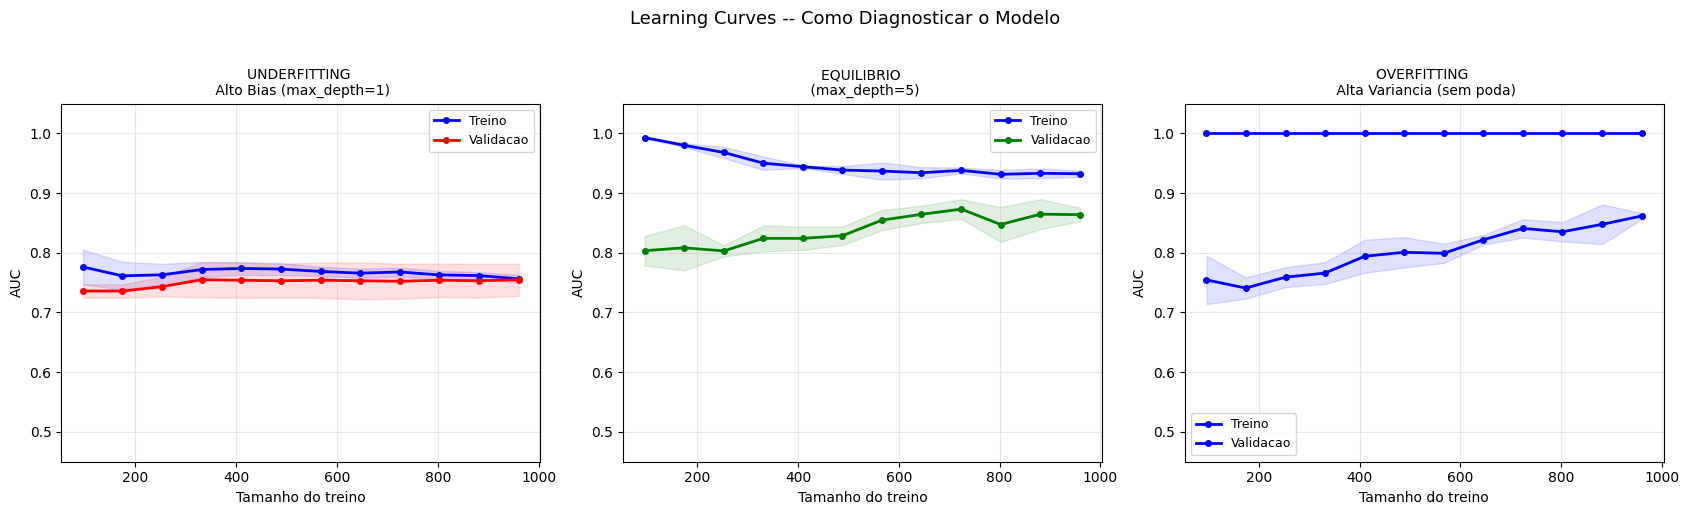

COMO LER A LEARNING CURVE:

UNDERFITTING (vermelho):
  Treino E validacao convergem para valor BAIXO
  Mais dados nao resolve -- o modelo e simples demais
  Solucao: modelo mais complexo, mais features, menos regularizacao

OVERFITTING (azul):
  GAP grande: treino alto, validacao baixa
  Mais dados AJUDA -- o gap vai fechando
  Solucao: regularizacao, simplificar modelo, feature selection

EQUILIBRIO (verde):
  Treino e validacao convergem para valor BOM
  Modelo bem calibrado, pronto para producao


In [ ]:
# ============================================================
# 5.3 -- LEARNING CURVES: DIAGNOSTICANDO O MODELO
# ============================================================

np.random.seed(42)
X_lc, y_lc = make_classification(
    n_samples=1200,    # dataset suficientemente grande para ver o padrao
    n_features=10,
    n_informative=6,
    random_state=42
)

# Tres configuracoes para ilustrar os tres diagnosticos
modelos_lc = [
    (DecisionTreeClassifier(max_depth=1),    "UNDERFITTING \n Alto Bias (max_depth=1)", 'red'),
    (DecisionTreeClassifier(max_depth=5),    "EQUILIBRIO \n (max_depth=5)",             'green'),
    (DecisionTreeClassifier(max_depth=None), "OVERFITTING \n Alta Variancia (sem poda)",'blue'),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (modelo, titulo, cor) in zip(axes, modelos_lc):
    # learning_curve calcula AUC para diferentes tamanhos de treino
    sizes, scores_tr, scores_va = learning_curve(
        modelo, X_lc, y_lc,
        cv=5,                                    # 5-fold CV em cada tamanho
        scoring='roc_auc',
        train_sizes=np.linspace(0.1, 1.0, 12),  # de 10% a 100% do dado
        random_state=42
    )

    # Media e desvio entre os folds para cada tamanho
    tr_mean = scores_tr.mean(axis=1)   # media dos 5 folds (eixo 1 = folds)
    tr_std  = scores_tr.std(axis=1)
    va_mean = scores_va.mean(axis=1)
    va_std  = scores_va.std(axis=1)

    # Curva de treino e validacao
    ax.plot(sizes, tr_mean, 'b-o', ms=4, lw=2, label='Treino')
    ax.plot(sizes, va_mean, f'{cor[0]}-o', ms=4, lw=2, label='Validacao')

    # Faixa de incerteza: media +/- 1 desvio padrao
    ax.fill_between(sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.12, color='blue')
    ax.fill_between(sizes, va_mean-va_std, va_mean+va_std, alpha=0.12, color=cor)

    ax.set_xlabel('Tamanho do treino')
    ax.set_ylabel('AUC')
    ax.set_ylim(0.45, 1.05)
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Learning Curves -- Como Diagnosticar o Modelo', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("COMO LER A LEARNING CURVE:")
print()
print("UNDERFITTING (vermelho):")
print("  Treino E validacao convergem para valor BAIXO")
print("  Mais dados nao resolve -- o modelo e simples demais")
print("  Solucao: modelo mais complexo, mais features, menos regularizacao")
print()
print("OVERFITTING (azul):")
print("  GAP grande: treino alto, validacao baixa")
print("  Mais dados AJUDA -- o gap vai fechando")
print("  Solucao: regularizacao, simplificar modelo, feature selection")
print()
print("EQUILIBRIO (verde):")
print("  Treino e validacao convergem para valor BOM")
print("  Modelo bem calibrado, pronto para producao")

In [ ]:
# ============================================================
# QUESTOES DO MODULO 5
# ============================================================

print("=" * 65)
print("QUESTOES DO MODULO 5 -- Resolva no papel antes de ver")
print("=" * 65)
print()
print("QUESTAO 1 (erro classico):")
print("  Um colega avaliou o modelo assim:")
print("  ")
print("    scaler = StandardScaler()")
print("    X_scaled = scaler.fit_transform(X)  # linha A")
print("    X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y)")
print("    scores = cross_val_score(modelo, X_tr, y_tr, cv=5)  # linha C")
print("  ")
print("  Ha um erro? Qual linha? Como corrigir?")
print()
print("QUESTAO 2 (diagnostico):")
print("  Learning curve mostra:")
print("  - AUC treino = 0.97 constante em todos os tamanhos")
print("  - AUC validacao = 0.63 com 100 amostras, 0.75 com 1000 amostras")
print("  ")
print("  (a) Qual o diagnostico?")
print("  (b) Mais dados resolve? Por que?")
print("  (c) Quais outras solucoes voce tentaria?")
print()
print("QUESTAO 3 (calculo):")
print("  cross_validate retornou: test_score = [-0.43, -0.51, -0.47, -0.49, -0.45]")
print("  scoring = 'neg_log_loss'")
print("  ")
print("  Qual o Log Loss medio? Como reportar?")
print()
print("-" * 65)

import numpy as np
scores_q3 = np.array([-0.43, -0.51, -0.47, -0.49, -0.45])
ll_medio = -scores_q3.mean()
ll_std   = scores_q3.std()

print("GABARITOS:")
print()
print("Q1: O erro esta na LINHA A.")
print("  scaler.fit_transform(X) usa media/desvio de X COMPLETO,")
print("  incluindo os dados de teste -- isso e data leakage.")
print("  A linha C ainda usa X_tr, mas X_tr ja foi contaminado pela linha A.")
print()
print("  CORRETO: usar Pipeline dentro do cross_val_score:")
print("    pipe = Pipeline([('sc', StandardScaler()), ('mod', modelo)])")
print("    scores = cross_val_score(pipe, X, y, cv=5)")
print("  O Pipeline re-fita o scaler APENAS no fold de treino, em cada iteracao.")
print()
print("Q2:")
print("  (a) OVERFITTING (alta variancia).")
print("      Treino perfeito mas validacao ruim = modelo memorizou os dados de treino.")
print()
print("  (b) SIM, mais dados ajuda neste caso.")
print("      Com mais dados, a validacao sobe de 0.63 para 0.75.")
print("      Overfitting melhora com mais dados porque o modelo tem menos chance")
print("      de memorizar -- ha mais variacao para generalizar.")
print("      (Diferente de underfitting, onde mais dados nao resolve.)")
print()
print("  (c) Outras solucoes:")
print("      - Regularizacao (L1/L2 na logistica, lambda no XGBoost)")
print("      - Reduzir complexidade (max_depth menor em arvores)")
print("      - Feature selection (remover variaveis com ruido)")
print("      - Dropout (se for rede neural)")
print()
print(f"Q3: Log Loss = -({scores_q3.mean():.4f}) = {ll_medio:.4f}")
print()
print(f"  SEMPRE multiplique neg_* por -1.")
print()
print(f"  Reportar: 'Log Loss = {ll_medio:.4f} +/- {ll_std:.4f} (5-fold CV, KFold shuffle=False)'")

QUESTOES DO MODULO 5 -- Resolva no papel antes de ver

QUESTAO 1 (erro classico):
  Um colega avaliou o modelo assim:
  
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)  # linha A
    X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y)
    scores = cross_val_score(modelo, X_tr, y_tr, cv=5)  # linha C
  
  Ha um erro? Qual linha? Como corrigir?

QUESTAO 2 (diagnostico):
  Learning curve mostra:
  - AUC treino = 0.97 constante em todos os tamanhos
  - AUC validacao = 0.63 com 100 amostras, 0.75 com 1000 amostras
  
  (a) Qual o diagnostico?
  (b) Mais dados resolve? Por que?
  (c) Quais outras solucoes voce tentaria?

QUESTAO 3 (calculo):
  cross_validate retornou: test_score = [-0.43, -0.51, -0.47, -0.49, -0.45]
  scoring = 'neg_log_loss'
  
  Qual o Log Loss medio? Como reportar?

-----------------------------------------------------------------
GABARITOS:

Q1: O erro esta na LINHA A.
  scaler.fit_transform(X) usa media/desvio de X COMPLETO,
  incluindo os dados

---
# MODULO 6 -- Regularizacao: Ridge, Lasso, Elastic Net
## Prioridade: ALTA | ISLP Capitulo 6

---

## A analogia que explica regularizacao

**O aluno que decora tudo vs o aluno que entende:**

Aluno A decora cada questao de cada prova antiga.
Na prova real, se cair a mesma questao: acerta.
Se mudar qualquer detalhe: erra completamente.
Ele tem muitos "parametros memorizados" (coeficientes grandes).

Regularizacao e o professor que diz: "voce so pode escrever respostas
de ate 10 linhas" -- forca o aluno a ser conciso, a generalizar.
O aluno que resume bem entende melhor e erra menos em questoes novas.

---

## 6A. As tres formas matematicas

**Ridge (L2):**
```
Loss = RSS + lambda * sum(beta_j ^ 2)
```
- Penaliza o QUADRADO dos coeficientes
- Efeito: encolhe todos em direcao a zero
- NUNCA zera completamente (por causa do quadrado)
- Util: quando todas as variaveis provavelmente importam

**Lasso (L1):**
```
Loss = RSS + lambda * sum(|beta_j|)
```
- Penaliza o VALOR ABSOLUTO dos coeficientes
- Efeito: pode ZERAR coeficientes completamente
- Resulta em selecao automatica de variaveis
- Util: quando suspeita que muitas variaveis sao irrelevantes

**Elastic Net:**
```
Loss = RSS + lambda * [l1_ratio * L1 + (1-l1_ratio) * L2]
```
- Combinacao de L1 e L2
- l1_ratio=0: Ridge puro | l1_ratio=1: Lasso puro
- Util: variaveis correlacionadas + selecao de variaveis

---

## 6B. A confusao mais comum -- C vs alpha

[!] ESTA CONFUSAO CAI EM TODA PROVA.

| Modelo sklearn | Parametro | Regularizacao forte = |
|----------------|-----------|----------------------|
| Ridge, Lasso, ElasticNet | `alpha` | alpha GRANDE |
| LogisticRegression, SVC | `C` | C PEQUENO (C = 1/alpha) |

Mnemonica: **C como Capacidade**
C grande = mais capacidade = menos regularizacao = pode overfittar
C pequeno = menos capacidade = mais regularizacao = modelo simples

---

## 6C. Efeito dos extremos de lambda (Q14 da prova real)

- lambda = 0: sem penalidade -> **modelo identico ao OLS (regressao linear pura)**
- lambda -> infinito: coeficientes -> **ZERO** (nunca -> infinito!)

[!] "Lambda grande faz coeficientes crescerem" -> FALSO.
Lambda grande ENCOLHE os coeficientes em direcao a zero.
Erro classico que caiu na Q14 da prova de 2019.

---

## 6D. Normalizar antes de regularizar -- por que?

Regularizacao penaliza o TAMANHO dos coeficientes.
Se 'volume_transac' esta em milhoes e 'n_produtos' esta entre 1-10,
o coeficiente de 'volume_transac' sera naturalmente menor -- a regularizacao
vai penalizar mais 'n_produtos' injustamente.

**Sempre use StandardScaler antes de Ridge/Lasso/ElasticNet.**


In [ ]:
# ============================================================
# 6.1 -- RIDGE vs LASSO vs ELASTIC NET
# ============================================================

np.random.seed(42)
n6, p6 = 500, 30   # 500 observacoes, 30 variaveis preditoras

# Dataset com esparsidade: apenas 8 das 30 variaveis sao relevantes
X6 = np.random.randn(n6, p6)   # variaveis preditoras geradas aleatoriamente

# Coeficientes verdadeiros (so conhecemos em simulacao, nunca na vida real)
beta_real = np.zeros(p6)
beta_real[:8] = [3.0, -2.5, 2.0, -1.8, 1.5, -1.0, 0.8, -0.6]  # 8 variaveis com efeito

# Y = Xbeta + ruido gaussiano
y6 = X6 @ beta_real + np.random.randn(n6) * 1.5

# NORMALIZAR antes de regularizar (obrigatorio para comparacao justa)
scaler6 = StandardScaler()
X6_norm = scaler6.fit_transform(X6)

# CV para estimar performance sem ver o conjunto de teste
kf6 = KFold(n_splits=5, shuffle=False)

print("=== OLS vs RIDGE vs LASSO vs ELASTIC NET ===")
print()
print(f"  Variaveis reais: 8 de {p6}")
print(f"  Variaveis irrelevantes: {p6-8} de {p6}")
print()
print(f"{'Modelo':<30} {'Coefs=0':>8} {'Coefs!=0':>9} {'MSE Val':>10}  Observacao")
print("-" * 78)

modelos6 = {
    'OLS (sem regularizacao)':    LinearRegression(),
    'Ridge (alpha=1.0)':          Ridge(alpha=1.0),
    'Ridge (alpha=10.0)':         Ridge(alpha=10.0),
    'Lasso (alpha=0.1)':          Lasso(alpha=0.1, max_iter=10000),
    'Lasso (alpha=1.0)':          Lasso(alpha=1.0, max_iter=10000),
    'ElasticNet (a=0.1, r=0.5)':  ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
}

for nome, modelo in modelos6.items():
    modelo.fit(X6_norm, y6)   # treina no dado normalizado completo

    coefs     = modelo.coef_
    n_zeros   = (np.abs(coefs) < 1e-6).sum()   # coeficientes efetivamente zero
    n_nonzero = p6 - n_zeros

    # MSE de validacao via CV (estimativa honesta)
    res6 = cross_validate(modelo, X6_norm, y6, cv=kf6,
                           scoring='neg_mean_squared_error')
    mse_val = -res6['test_score'].mean()  # neg_* -> multiplicar por -1

    # Verificando qualidade da selecao
    if n_zeros > 0:
        corretas  = (np.abs(coefs[:8]) > 1e-6).sum()   # reais mantidas
        erradas   = (np.abs(coefs[8:]) > 1e-6).sum()   # irrelevantes mantidas
        obs = f"{corretas}/8 reais, {erradas}/{p6-8} irrelevantes"
    else:
        obs = "mantem todas -- sem selecao"

    print(f"{nome:<30} {n_zeros:>8} {n_nonzero:>9} {mse_val:>10.4f}  {obs}")

print()
print("INTERPRETACAO:")
print("  OLS: sem penalidade -- coeficientes livres para overfittar")
print("  Ridge alpha=1: encolhe mas nao elimina -- mantem todas as 30 vars")
print("  Ridge alpha=10: encolhe mais -- ainda nao elimina nenhuma")
print("  Lasso alpha=0.1: elimina irrelevantes, mantem a maioria das reais")
print("  Lasso alpha=1.0: forte demais -- elimina variaveis reais tambem!")
print("  ElasticNet: equilibrio entre selecao e estabilidade")

=== OLS vs RIDGE vs LASSO vs ELASTIC NET ===

  Variaveis reais: 8 de 30
  Variaveis irrelevantes: 22 de 30

Modelo                          Coefs=0  Coefs!=0    MSE Val  Observacao
------------------------------------------------------------------------------
OLS (sem regularizacao)               0        30     2.4053  mantem todas -- sem selecao
Ridge (alpha=1.0)                     0        30     2.4049  mantem todas -- sem selecao
Ridge (alpha=10.0)                    0        30     2.4194  mantem todas -- sem selecao
Lasso (alpha=0.1)                    18        12     2.4492  8/8 reais, 4/22 irrelevantes
Lasso (alpha=1.0)                    25         5     9.4173  5/8 reais, 0/22 irrelevantes
ElasticNet (a=0.1, r=0.5)            11        19     2.5117  8/8 reais, 11/22 irrelevantes

INTERPRETACAO:
  OLS: sem penalidade -- coeficientes livres para overfittar
  Ridge alpha=1: encolhe mas nao elimina -- mantem todas as 30 vars
  Ridge alpha=10: encolhe mais -- ainda nao elimin

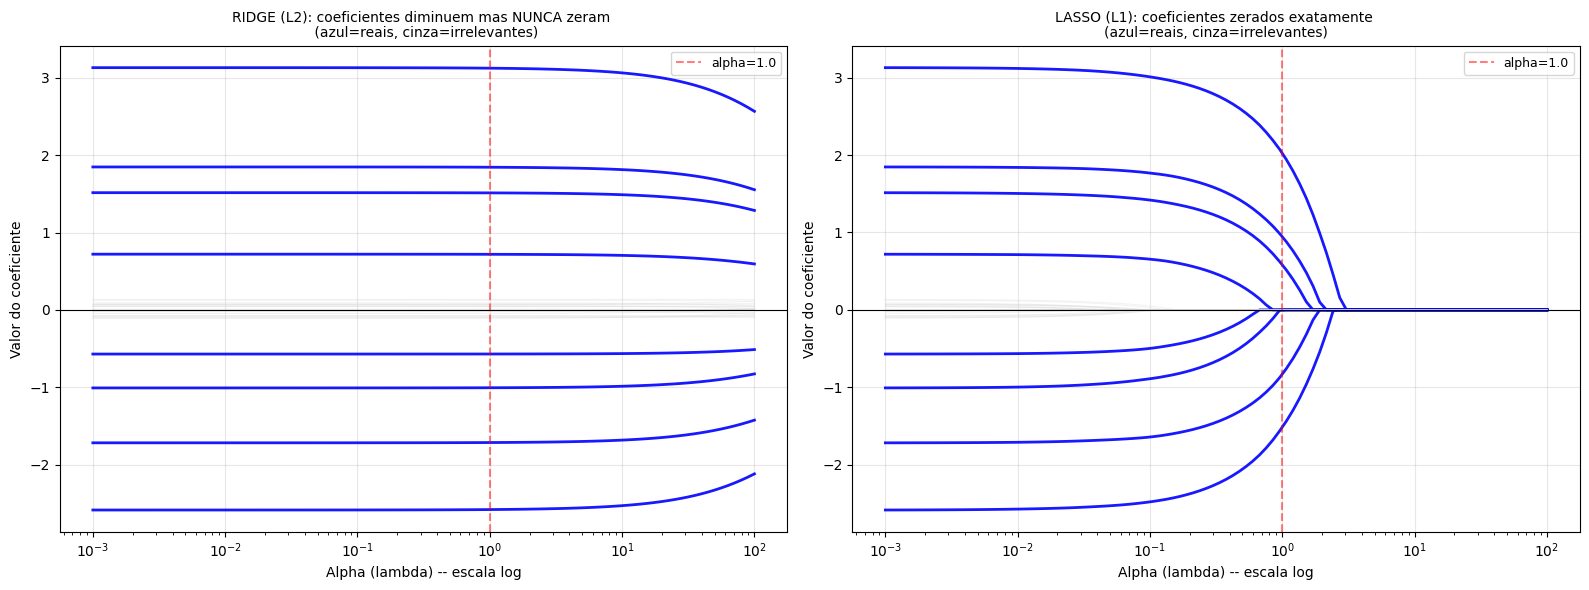

[!] PEGADINHAS CRITICAS SOBRE LAMBDA:

  VERDADEIRO: 'lambda=0 em Ridge = regressao linear pura'
    Sem penalidade, a loss = RSS = OLS classico

  FALSO: 'lambda->infinito -> coeficientes -> infinito'
  CORRETO: 'lambda->infinito -> coeficientes -> ZERO'
    Lambda grande ENCOLHE em direcao a zero, nunca expande
    Esta foi a Q14 da prova de 2019 -- candidatos erraram isso!

TABELA DE CONVERSAO C <-> LAMBDA (LogReg e SVM):
         C    lambda=1/C  Regularizacao
  ----------------------------------------
     0.001      1000.000  MUITO FORTE
     0.010       100.000  forte
     0.100        10.000  moderada
     1.000         1.000  moderada (default sklearn)
    10.000         0.100  fraca
   100.000         0.010  MUITO FRACA

[!] C=0.001 em LogisticRegression = regularizacao MUITO FORTE
    (nao fraca -- erro classico de entrevista!)


In [ ]:
# ============================================================
# 6.2 -- CAMINHO DOS COEFICIENTES vs LAMBDA
# ============================================================

# Visualizando como os coeficientes mudam conforme aumentamos a penalidade
alphas_range = np.logspace(-3, 2, 100)  # 100 valores entre 0.001 e 100

coefs_ridge = []  # lista para guardar os coeficientes de cada alpha
coefs_lasso = []

for a in alphas_range:
    # Ridge: treina e guarda os coeficientes para esse valor de alpha
    r = Ridge(alpha=a)
    r.fit(X6_norm, y6)
    coefs_ridge.append(r.coef_.copy())  # .copy() evita que a lista aponte ao mesmo array

    # Lasso: treina e guarda os coeficientes
    l = Lasso(alpha=a, max_iter=10000)
    l.fit(X6_norm, y6)
    coefs_lasso.append(l.coef_.copy())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i in range(p6):
    # Variaveis reais (primeiras 8): linha grossa azul
    # Variaveis irrelevantes: linha fina cinza
    cor       = 'blue'  if i < 8 else 'lightgray'
    lw        = 2.0     if i < 8 else 0.7
    alpha_plt = 0.9     if i < 8 else 0.3

    axes[0].plot(alphas_range, [c[i] for c in coefs_ridge],
                 color=cor, lw=lw, alpha=alpha_plt)
    axes[1].plot(alphas_range, [c[i] for c in coefs_lasso],
                 color=cor, lw=lw, alpha=alpha_plt)

for ax, titulo in zip(axes, [
    'RIDGE (L2): coeficientes diminuem mas NUNCA zeram \n (azul=reais, cinza=irrelevantes)',
    'LASSO (L1): coeficientes zerados exatamente \n(azul=reais, cinza=irrelevantes)'
]):
    ax.set_xscale('log')              # escala logaritmica para ver toda a faixa
    ax.set_xlabel('Alpha (lambda) -- escala log')
    ax.set_ylabel('Valor do coeficiente')
    ax.set_title(titulo, fontsize=10)
    ax.axvline(1.0, color='red', linestyle='--', alpha=0.5, label='alpha=1.0')
    ax.axhline(0, color='black', lw=0.8)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("[!] PEGADINHAS CRITICAS SOBRE LAMBDA:")
print()
print("  VERDADEIRO: 'lambda=0 em Ridge = regressao linear pura'")
print("    Sem penalidade, a loss = RSS = OLS classico")
print()
print("  FALSO: 'lambda->infinito -> coeficientes -> infinito'")
print("  CORRETO: 'lambda->infinito -> coeficientes -> ZERO'")
print("    Lambda grande ENCOLHE em direcao a zero, nunca expande")
print("    Esta foi a Q14 da prova de 2019 -- candidatos erraram isso!")
print()
print("TABELA DE CONVERSAO C <-> LAMBDA (LogReg e SVM):")
print(f"  {'C':>8}  {'lambda=1/C':>12}  Regularizacao")
print("  " + "-" * 40)
for c_val, desc in [
    (0.001, "MUITO FORTE"),
    (0.01,  "forte"),
    (0.1,   "moderada"),
    (1.0,   "moderada (default sklearn)"),
    (10.0,  "fraca"),
    (100.0, "MUITO FRACA"),
]:
    print(f"  {c_val:>8.3f}  {1/c_val:>12.3f}  {desc}")

print()
print("[!] C=0.001 em LogisticRegression = regularizacao MUITO FORTE")
print("    (nao fraca -- erro classico de entrevista!)")

=== COMO ESCOLHER O MELHOR ALPHA ===

Nao existe um alpha magico para todos os datasets.
A unica forma correta: testar varios e usar CV.



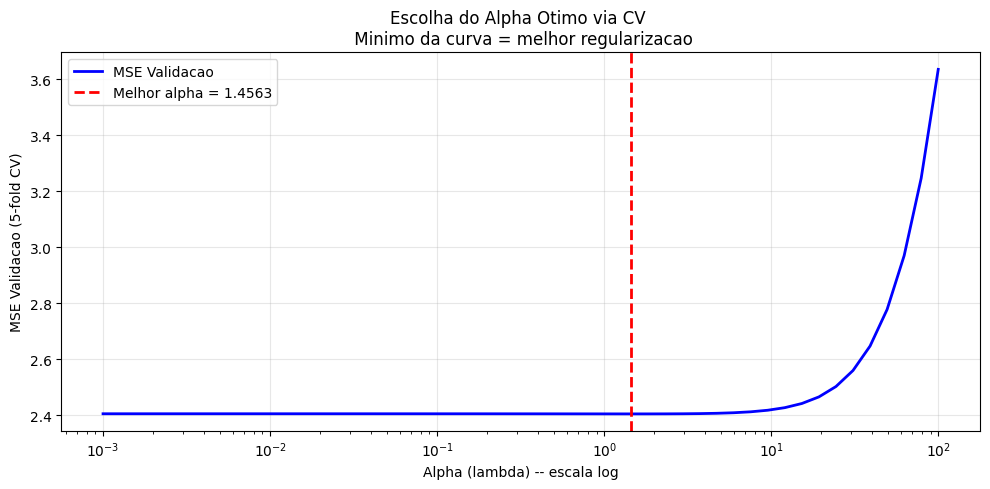

Melhor alpha para Ridge: 1.4563
MSE de validacao:         2.4048

PROCESSO COMPLETO (como fazer na pratica):
  1. Definir grade de alphas: np.logspace(-3, 2, 50)
  2. Para cada alpha: cross_validate e calcular MSE de validacao
  3. Escolher alpha com menor MSE de validacao
  4. Re-treinar no treino completo com esse alpha
  5. Avaliar UMA UNICA VEZ no conjunto de teste

ATALHO DO SKLEARN (mais elegante):
  from sklearn.linear_model import RidgeCV
  modelo = RidgeCV(alphas=np.logspace(-3,2,50), cv=5)
  modelo.fit(X_treino, y_treino)  # ja encontra o melhor alpha
  print(modelo.alpha_)  # melhor alpha encontrado


In [ ]:
# ============================================================
# 6.3 -- ESCOLHENDO O MELHOR ALPHA VIA CV
# ============================================================

print("=== COMO ESCOLHER O MELHOR ALPHA ===")
print()
print("Nao existe um alpha magico para todos os datasets.")
print("A unica forma correta: testar varios e usar CV.")
print()

alphas_test = np.logspace(-3, 2, 50)  # 50 valores para testar
mse_vals    = []

for a in alphas_test:
    res = cross_validate(Ridge(alpha=a), X6_norm, y6,
                          cv=kf6, scoring='neg_mean_squared_error')
    mse_vals.append(-res['test_score'].mean())  # neg_* -> positivo

# Encontrando o alpha que minimiza o MSE de validacao
melhor_alpha = alphas_test[np.argmin(mse_vals)]
melhor_mse   = min(mse_vals)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas_test, mse_vals, 'b-', lw=2, label='MSE Validacao')
ax.axvline(melhor_alpha, color='red', linestyle='--', lw=2,
           label=f'Melhor alpha = {melhor_alpha:.4f}')
ax.set_xscale('log')
ax.set_xlabel('Alpha (lambda) -- escala log')
ax.set_ylabel('MSE Validacao (5-fold CV)')
ax.set_title('Escolha do Alpha Otimo via CV \n Minimo da curva = melhor regularizacao')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Melhor alpha para Ridge: {melhor_alpha:.4f}")
print(f"MSE de validacao:         {melhor_mse:.4f}")
print()
print("PROCESSO COMPLETO (como fazer na pratica):")
print("  1. Definir grade de alphas: np.logspace(-3, 2, 50)")
print("  2. Para cada alpha: cross_validate e calcular MSE de validacao")
print("  3. Escolher alpha com menor MSE de validacao")
print("  4. Re-treinar no treino completo com esse alpha")
print("  5. Avaliar UMA UNICA VEZ no conjunto de teste")
print()
print("ATALHO DO SKLEARN (mais elegante):")
print("  from sklearn.linear_model import RidgeCV")
print("  modelo = RidgeCV(alphas=np.logspace(-3,2,50), cv=5)")
print("  modelo.fit(X_treino, y_treino)  # ja encontra o melhor alpha")
print("  print(modelo.alpha_)  # melhor alpha encontrado")

In [ ]:
# ============================================================
# QUESTOES DO MODULO 6
# ============================================================

print("=" * 65)
print("QUESTOES DO MODULO 6 -- Resolva antes de ver o gabarito")
print("=" * 65)
print()
print("QUESTAO 1 (selecao de modelo):")
print("  Voce tem 60 variaveis preditoras.")
print("  Suspeita que apenas 10-15 sao realmente relevantes.")
print()
print("  (a) Qual regularizacao escolheria? Por que?")
print("  (b) Se 5 dessas variaveis relevantes forem correlacionadas entre si,")
print("      como isso afeta a escolha?")
print()
print("QUESTAO 2 (C vs alpha -- pegadinha classica):")
print("  Colega diz: 'Estou com LogisticRegression com C=0.001.")
print("  Como a regularizacao e fraca, o modelo pode overfittar.'")
print()
print("  Ele esta certo? Explique o erro se houver.")
print()
print("QUESTAO 3 (lambda -- Q14 da prova real):")
print("  Ridge com lambda=0 vs Ridge com lambda=1000.")
print("  O que acontece com os coeficientes em cada caso?")
print()
print("-" * 65)
print()
print("GABARITOS:")
print()
print("Q1:")
print("  (a) Lasso (ou Elastic Net).")
print("      Com muitas variaveis irrelevantes, Lasso e ideal:")
print("      ele ZERA os coeficientes das variaveis irrelevantes automaticamente.")
print("      Ridge so encolhe -- mantem todas as 60 variaveis.")
print("      Se nao souber qual usar: comece com Elastic Net (l1_ratio=0.5),")
print("      mais flexivel e captura o melhor dos dois.")
print()
print("  (b) Com 5 variaveis correlacionadas entre si, o Lasso tem problema:")
print("      ele escolhe ARBITRARIAMENTE uma delas e zera as outras 4.")
print("      O resultado e instavel: amostras diferentes -> variaveis diferentes escolhidas.")
print("      Solucao: Elastic Net.")
print("      O componente L2 faz com que variaveis correlacionadas tenham")
print("      coeficientes similares e menores, em vez de um ganhar tudo e os outros zerem.")
print()
print("Q2: O colega esta ERRADO.")
print("  C = 1/lambda, entao C=0.001 corresponde a lambda=1000.")
print("  Lambda grande = regularizacao FORTE = modelo simples = pode UNDERFIT.")
print("  C=0.001: penalidade enorme, coeficientes muito pequenos.")
print("  Para ter regularizacao fraca (risco de overfit): use C grande (100, 1000).")
print()
print("  Mnemonica: C como Capacidade.")
print("  C grande = mais capacidade = menos restricao = pode overfittar.")
print("  C pequeno = menos capacidade = mais restricao = pode underfittar.")
print()
print("Q3:")
print("  lambda=0: sem penalidade -> identico ao OLS classico.")
print("    A loss e apenas RSS. Coeficientes = minimos quadrados normais.")
print("    'VERDADEIRO: lambda=0 em Ridge = regressao linear pura'")
print()
print("  lambda=1000: penalidade fortissima -> coeficientes -> 0 (mas nunca exatamente 0).")
print("    O modelo minimiza fortemente o termo de penalidade,")
print("    forcando os betas a serem muito pequenos.")
print("    'FALSO: lambda grande faz coeficientes crescerem'")
print("    'VERDADEIRO: lambda->inf faz coeficientes->0 (nunca->infinito!)'")
print("    Esta foi a Q14 da prova de 2019.")

QUESTOES DO MODULO 6 -- Resolva antes de ver o gabarito

QUESTAO 1 (selecao de modelo):
  Voce tem 60 variaveis preditoras.
  Suspeita que apenas 10-15 sao realmente relevantes.

  (a) Qual regularizacao escolheria? Por que?
  (b) Se 5 dessas variaveis relevantes forem correlacionadas entre si,
      como isso afeta a escolha?

QUESTAO 2 (C vs alpha -- pegadinha classica):
  Colega diz: 'Estou com LogisticRegression com C=0.001.
  Como a regularizacao e fraca, o modelo pode overfittar.'

  Ele esta certo? Explique o erro se houver.

QUESTAO 3 (lambda -- Q14 da prova real):
  Ridge com lambda=0 vs Ridge com lambda=1000.
  O que acontece com os coeficientes em cada caso?

-----------------------------------------------------------------

GABARITOS:

Q1:
  (a) Lasso (ou Elastic Net).
      Com muitas variaveis irrelevantes, Lasso e ideal:
      ele ZERA os coeficientes das variaveis irrelevantes automaticamente.
      Ridge so encolhe -- mantem todas as 60 variaveis.
      Se nao souber q

---
# MODULO 7 -- Alem da Linearidade
## Prioridade: MEDIA | ISLP Capitulo 7

---

## Por que ir alem?

**Analogia:** imagine prever o numero de clientes em uma loja ao longo do dia.
Das 8h as 11h: sobe gradualmente.
Das 11h ao 14h: pico do almoco, sobe rapido.
Das 14h as 17h: cai.
Das 17h as 20h: segundo pico, sobe de novo.

Uma reta nao captura isso. Precisamos de funcoes que mudem de comportamento.

---

## 7A. Regressao Polinomial

Adiciona X^2, X^3, ... como variaveis novas.
O modelo continua sendo linear nos parametros (beta), mas nao em X.

**Problema:** grau alto = instabilidade nas bordas (Runge's phenomenon).
Um polinomio de grau 15 pode ter oscilacoes absurdas fora do intervalo de treino.
Nunca use grau > 5 sem verificar o comportamento nas bordas.

---

## 7B. Splines -- a solucao recomendada

**Definicao:** polinomios por partes com continuidade nos pontos de juncao (nos).

Natural Cubic Spline:
- Polinomio cubico (grau 3) entre cada par de nos
- Continuidade da 1a e 2a derivada nos nos (curva suave)
- Linha reta nas extremidades (extrapola de forma estavel)

**Vantagem sobre polinomial de alto grau:**
- Flexivel localmente
- Estavel nas bordas
- Numero de nos controla a complexidade

---

## 7C. GAMs (Generalized Additive Models)

Cada variavel contribui com sua propria funcao suave:
```
Y = beta_0 + f1(X1) + f2(X2) + ... + fp(Xp) + epsilon
```

Util no contexto bancario para modelar:
- Relacao nao-linear entre score e probabilidade de default
- Efeito do tempo de conta no NPS (cresce, estabiliza, cai levemente)


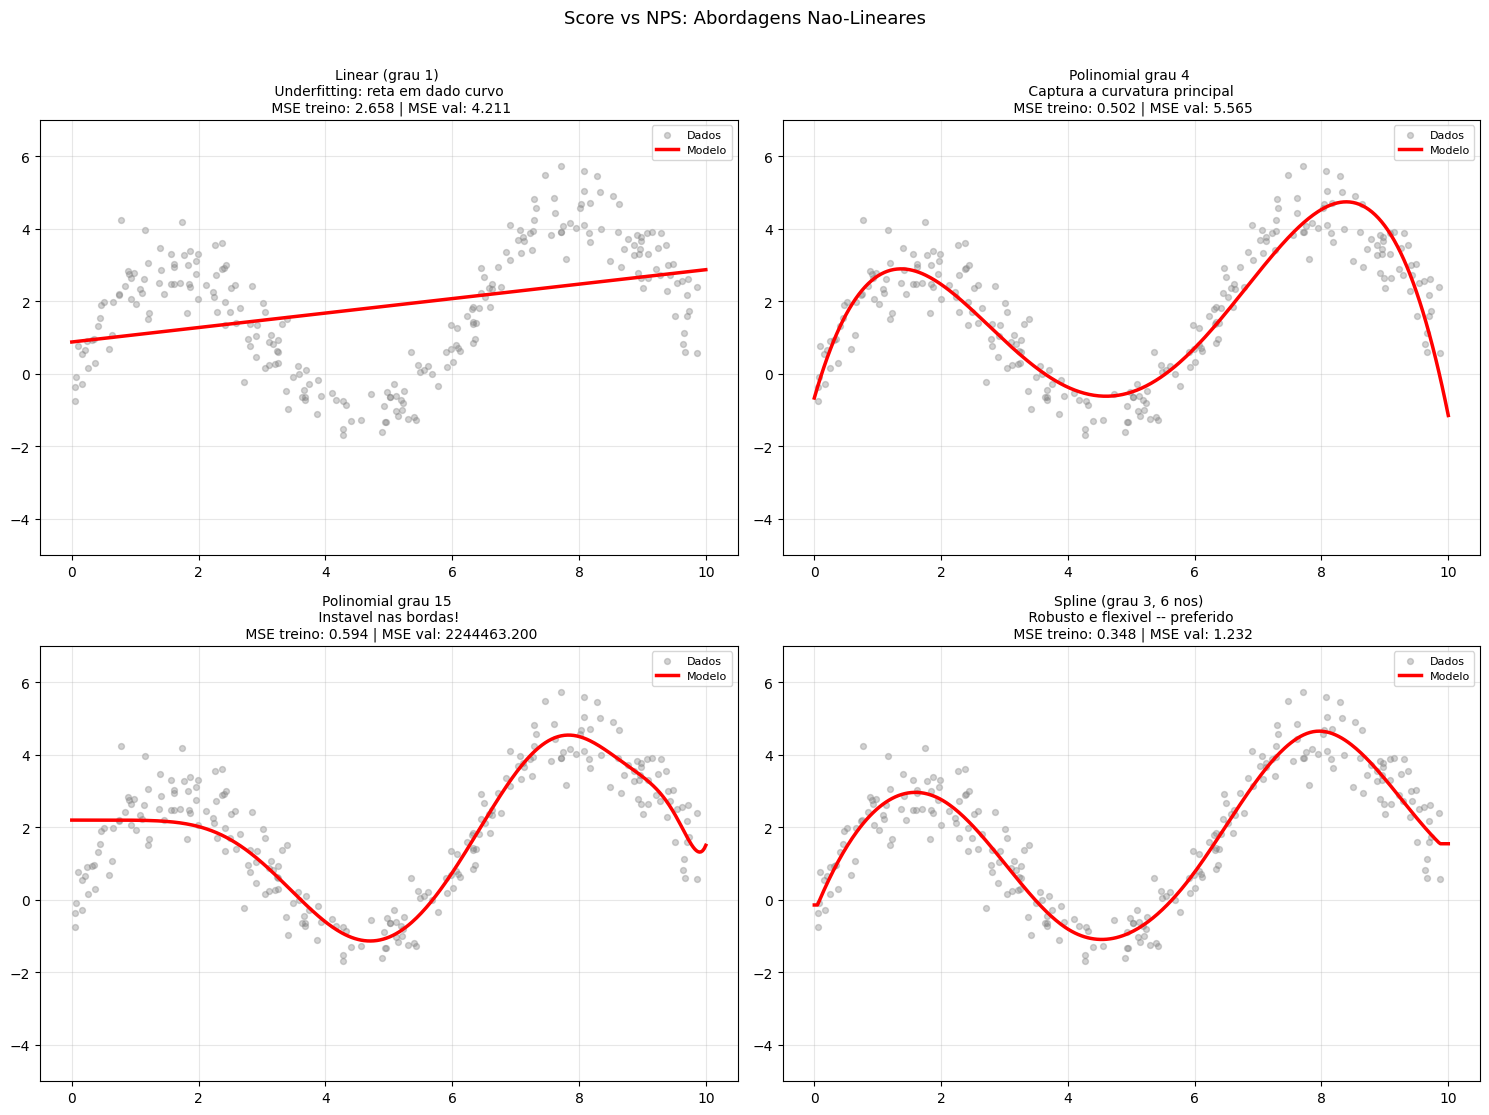

RESUMO:

  Linear:         MSE val alto. Reta nao captura a curvatura.
  Polinomial g4:  Bom ajuste. Captura o padrao principal.
  Polinomial g15: MSE treino baixo, MSE val alto. Overfitting nas bordas.
  Spline:         Melhor balance. Flexivel e estavel.

QUANDO USAR:
  Polinomial grau 2-3: curvatura simples (parabola, S suave)
  Splines:             relacao complexa sem instabilidade -- recomendado
  GAMs:                multiplas variaveis cada uma com sua propria curva

[!] NUNCA use polinomial grau > 5 sem verificar o comportamento nas bordas.
    O modelo pode prever valores absurdos fora do intervalo de treino.
    Splines sao mais seguros para extrapolacao.


In [ ]:
# ============================================================
# 7.1 -- COMPARANDO ABORDAGENS NAO-LINEARES
# ============================================================

np.random.seed(42)

# Dados com relacao claramente nao-linear
# Contexto: score de saude financeira (X) vs NPS (Y)
n7 = 250
X7 = np.sort(np.random.uniform(0, 10, n7)).reshape(-1, 1)

# Relacao real: nao-linear (seno + tendencia linear suave)
y7 = np.sin(X7.ravel()) * 2.5 + 0.25*X7.ravel() + np.random.normal(0, 0.6, n7)

X_plot7 = np.linspace(0, 10, 400).reshape(-1, 1)  # pontos finos para plot suave
kf7 = KFold(n_splits=5, shuffle=False)

# Quatro abordagens, da mais simples a mais sofisticada
modelos7 = [
    ("Linear (grau 1) \n Underfitting: reta em dado curvo",
     Pipeline([('p', PolynomialFeatures(degree=1)), ('lr', LinearRegression())])),

    ("Polinomial grau 4 \n Captura a curvatura principal",
     Pipeline([('p', PolynomialFeatures(degree=4)), ('lr', LinearRegression())])),

    ("Polinomial grau 15 \n Instavel nas bordas!",
     Pipeline([('p', PolynomialFeatures(degree=15)), ('lr', LinearRegression())])),

    ("Spline (grau 3, 6 nos) \n Robusto e flexivel -- preferido",
     Pipeline([('s', SplineTransformer(degree=3, n_knots=6, include_bias=False)),
               ('lr', LinearRegression())])),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for ax7, (nome, modelo) in zip(axes.ravel(), modelos7):
    modelo.fit(X7, y7)  # treina no dado completo para visualizar

    mse_tr7 = mean_squared_error(y7, modelo.predict(X7))
    mse_va7 = -cross_validate(modelo, X7, y7, cv=kf7,
                               scoring='neg_mean_squared_error')['test_score'].mean()

    ax7.scatter(X7, y7, alpha=0.35, s=18, color='gray', label='Dados')
    ax7.plot(X_plot7, modelo.predict(X_plot7), 'r-', lw=2.5, label='Modelo')
    ax7.set_title(f'{nome} \n MSE treino: {mse_tr7:.3f} | MSE val: {mse_va7:.3f}', fontsize=10)
    ax7.set_ylim(-5, 7)
    ax7.legend(fontsize=8)

plt.suptitle('Score vs NPS: Abordagens Nao-Lineares', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("RESUMO:")
print()
print("  Linear:         MSE val alto. Reta nao captura a curvatura.")
print("  Polinomial g4:  Bom ajuste. Captura o padrao principal.")
print("  Polinomial g15: MSE treino baixo, MSE val alto. Overfitting nas bordas.")
print("  Spline:         Melhor balance. Flexivel e estavel.")
print()
print("QUANDO USAR:")
print("  Polinomial grau 2-3: curvatura simples (parabola, S suave)")
print("  Splines:             relacao complexa sem instabilidade -- recomendado")
print("  GAMs:                multiplas variaveis cada uma com sua propria curva")
print()
print("[!] NUNCA use polinomial grau > 5 sem verificar o comportamento nas bordas.")
print("    O modelo pode prever valores absurdos fora do intervalo de treino.")
print("    Splines sao mais seguros para extrapolacao.")

In [ ]:
# ============================================================
# QUESTOES DO MODULO 7
# ============================================================

print("=" * 65)
print("QUESTOES DO MODULO 7")
print("=" * 65)
print()
print("QUESTAO 1:")
print("  Voce plota 'tempo_conta' (anos) vs NPS e observa:")
print("  - 0 a 2 anos: NPS cresce rapido")
print("  - 2 a 5 anos: NPS estabiliza")
print("  - Apos 5 anos: NPS cresce levemente de novo")
print()
print("  (a) Modelo linear e adequado? Por que?")
print("  (b) Qual abordagem voce usaria?")
print()
print("QUESTAO 2:")
print("  Modelo polinomial grau 1: MSE treino=0.89, MSE val=0.91")
print("  Modelo polinomial grau 20: MSE treino=0.01, MSE val=8.72")
print()
print("  O que cada modelo esta fazendo errado?")
print("  Qual voce escolheria e como ajustaria?")
print()
print("-" * 65)
print()
print("GABARITOS:")
print()
print("Q1:")
print("  (a) Nao. A relacao tem tres fases distintas -- nao-linear.")
print("      Uma reta teria alto bias neste cenario: sempre errada em parte do dado.")
print()
print("  (b) Spline cubico com nos aos 2 anos e 5 anos (pontos onde muda o padrao).")
print("      Ou GAM com funcao suave para 'tempo_conta'.")
print()
print("      Nao use polinomial de grau alto: o dado vai de 0 a talvez 20-30 anos.")
print("      Com grau alto, as previsoes para clientes muito novos ou muito antigos")
print("      podem ser absurdas (NPS negativo ou acima de 10).")
print()
print("Q2:")
print("  Grau 1 (underfitting):")
print("    MSE treino = 0.89 e MSE val = 0.91 -- proximos, mas RUINS.")
print("    Sem overfitting, mas sem ajuste suficiente.")
print("    O modelo e simples demais -- nao captura a curvatura.")
print()
print("  Grau 20 (overfitting severo):")
print("    MSE treino = 0.01 -- quase zero, memorizou tudo.")
print("    MSE val = 8.72 -- falha completamente em dados novos.")
print()
print("  Escolha: comecar com grau 1 e aumentar gradualmente (3, 5).")
print("  Ou: usar Spline que e mais estavel que polinomial de alto grau.")
print("  Nunca escolher pelo MSE de treino -- sempre pelo MSE de validacao.")

QUESTOES DO MODULO 7

QUESTAO 1:
  Voce plota 'tempo_conta' (anos) vs NPS e observa:
  - 0 a 2 anos: NPS cresce rapido
  - 2 a 5 anos: NPS estabiliza
  - Apos 5 anos: NPS cresce levemente de novo

  (a) Modelo linear e adequado? Por que?
  (b) Qual abordagem voce usaria?

QUESTAO 2:
  Modelo polinomial grau 1: MSE treino=0.89, MSE val=0.91
  Modelo polinomial grau 20: MSE treino=0.01, MSE val=8.72

  O que cada modelo esta fazendo errado?
  Qual voce escolheria e como ajustaria?

-----------------------------------------------------------------

GABARITOS:

Q1:
  (a) Nao. A relacao tem tres fases distintas -- nao-linear.
      Uma reta teria alto bias neste cenario: sempre errada em parte do dado.

  (b) Spline cubico com nos aos 2 anos e 5 anos (pontos onde muda o padrao).
      Ou GAM com funcao suave para 'tempo_conta'.

      Nao use polinomial de grau alto: o dado vai de 0 a talvez 20-30 anos.
      Com grau alto, as previsoes para clientes muito novos ou muito antigos
      podem

---
# MODULO 8 -- Arvores, Random Forest, XGBoost
## Prioridade: MUITO ALTA | ISLP Capitulo 8

---

## A analogia do gerente experiente

Um gerente de credito experiente nao usa formula.
Ele pergunta uma serie de perguntas:
- "O faturamento anual e maior que R$500k?" -> Se sim: caminho A
- "Ha atraso nos ultimos 6 meses?" -> Se sim: caminho B
- "O setor e de risco alto?" -> Se sim: caminho C

Uma arvore de decisao faz exatamente isso:
divide o espaco de variaveis com regras sequenciais do tipo
"se X > c, vai para a esquerda; caso contrario, vai para a direita".

---

## 8A. Como a arvore decide onde dividir

Criterios de impureza (medindo "mistura" das classes em cada no):

**Gini:**
```
Gini = 1 - sum(p_k ^ 2)
```
Onde p_k = proporcao da classe k no no.
- No puro (so uma classe): Gini = 1 - 1^2 = 0
- No completamente misto: Gini = 1 - (0.5^2 + 0.5^2) = 0.5

**Entropia:**
```
Entropia = -sum(p_k * log2(p_k))
```
- No puro: Entropia = 0
- No completamente misto: Entropia = 1.0

A divisao escolhida e a que mais reduz a impureza media dos nos filhos.

---

## 8B. Profundidade maxima sem restricao

Com n amostras, a arvore pode ter profundidade maxima de:
```
ceil(log2(n))
```

- n = 100: ceil(log2(100)) = ceil(6.64) = 7
- n = 10M: ceil(log2(10.000.000)) = ceil(23.25) = **24**

[!] Esta formula cai em prova. Saiba calcular rapidamente.

---

## 8C. Por que arvores sozinhas sao frageis

Alta variancia: pequena mudanca nos dados -> arvore completamente diferente.
Sem restricao: memoriza tudo (Log Loss treino -> 0, val explode).

**Solucao:** combinar muitas arvores.

---

## 8D. Random Forest -- Bagging + Feature Randomness

- Treina K arvores, cada uma em uma amostra bootstrap diferente
- Em cada divisao, considera apenas sqrt(p) features aleatorias
- Previsao final: votacao (classificacao) ou media (regressao)

**Resultado:** variancias das arvores individuais se cancelam.
Mais arvores = mais estavel. Nunca causa mais overfitting.

**Overfitting em Random Forest vem de:**
- max_depth alto (arvores muito profundas)
- min_samples_leaf = 1 (folhas com 1 amostra so)

**Random Forest NAO tem learning_rate.** Isso e exclusivo de boosting.

---

## 8E. XGBoost -- Boosting Sequencial

- Treina arvores UMA DE CADA VEZ
- Cada nova arvore corrige os erros da anterior
- Usa `learning_rate` para controlar o tamanho do passo

**O que XGBoost tem que RF nao tem:**
- `learning_rate`: controla conservadorismo do boosting
- `early_stopping_rounds`: para quando val para de melhorar
- `reg_lambda` e `reg_alpha`: regularizacao L2 e L1
- `subsample` e `colsample_bytree`: amostragem por arvore

**Overfitting em XGBoost vem de:**
- learning_rate alto (0.3+) com muitas arvores
- max_depth alto (>8)
- sem regularizacao

---

## 8F. A diferenca critica que SEMPRE cai em prova

| | Random Forest | XGBoost |
|--|--------------|---------|
| Treino | PARALELO (arvores independentes) | SEQUENCIAL (cada uma corrige a anterior) |
| learning_rate | **NAO TEM** | **TEM** |
| early_stopping | Nao | Sim |
| Overfit via | max_depth alto | lr alto + muitas arvores |

**Q25 da prova:** "taxa de aprendizado causa overfitting em RF" -> ERRADO.
Random Forest NAO tem taxa de aprendizado.


In [ ]:
# ============================================================
# 8.1 -- EFEITO DA PROFUNDIDADE E LOG LOSS (Q20 DA PROVA)
# ============================================================

np.random.seed(42)
X8, y8 = make_classification(
    n_samples=1200,
    n_features=12,
    n_informative=6,
    n_redundant=3,      # 3 variaveis redundantes (combinacao das informativas)
    random_state=42
)

kf8_5  = KFold(n_splits=5,  shuffle=False)
kf8_10 = KFold(n_splits=10, shuffle=False)  # configuracao da Q20 da prova

print("=== EFEITO DA PROFUNDIDADE: criterion='entropy' ===")
print()
print(f"{'max_depth':>12} | {'Treino LL':>10} | {'Val LL':>10} | Diagnostico")
print("-" * 70)

for max_d in [None, 1, 2, 3, 5, 8, 15]:
    arv = DecisionTreeClassifier(
        criterion='entropy',  # usar informacao (entropia) para decidir divisoes
        max_depth=max_d,      # None = sem restricao -> overfitting total
        random_state=42
    )
    res8 = cross_validate(
        arv, X8, y8,
        cv=kf8_5,
        scoring='neg_log_loss',   # Log Loss: mede qualidade das probabilidades
        return_train_score=True
    )
    tr8 = -res8['train_score'].mean()   # neg_* -> positivo
    va8 = -res8['test_score'].mean()

    if max_d is None: d = "<- OVERFITTING: LL treino ~= 0, val explode"
    elif max_d <= 2:  d = "<- UNDERFITTING"
    elif max_d == 5:  d = "<- proximo do equilibrio"
    else:             d = ""
    print(f"{str(max_d):>12} | {tr8:>10.4f} | {va8:>10.4f} | {d}")

print()
print("=== Q20 DA PROVA 2019: arvore sem poda, 10 folds, Log Loss ===")
arv_q20 = DecisionTreeClassifier(criterion='entropy')  # sem poda = max_depth=None
res_q20 = cross_validate(arv_q20, X8, y8, cv=kf8_10,
                          scoring='neg_log_loss', return_train_score=True)
tr_q20 = -res_q20['train_score'].mean()
va_q20 = -res_q20['test_score'].mean()

print(f"  Treino Log Loss: {tr_q20:.4f}  <- overfitting perfeito")
print(f"  Val Log Loss:    {va_q20:.4f}")
print()
print("[!] POR QUE LOG LOSS TREINO ~= 0 COM ARVORE SEM PODA?")
print("  Arvore sem poda cria folhas com 1 amostra de uma so classe.")
print("  Probabilidade prevista no treino: 1.0 para a classe correta.")
print("  Log Loss com p=1.0 para Y=1: -log(1.0) = 0.")
print("  Todas as folhas puras -> Log Loss treino = 0.")
print()
print("[!] Log Loss E VALIDA para classificacao!")
print("  Mede a qualidade das PROBABILIDADES, nao so da classificacao.")
print("  Candidato da prova 2019 errou por nao saber isso.")
print()
print("=== PROFUNDIDADE MAXIMA: ceil(log2(n)) ===")
for n_ex in [1000, 100000, 10000000]:
    prof = math.ceil(math.log2(n_ex))
    print(f"  n={n_ex:>12,}: log2 = {math.log2(n_ex):.2f} -> ceil = {prof}")

=== EFEITO DA PROFUNDIDADE: criterion='entropy' ===

   max_depth |  Treino LL |     Val LL | Diagnostico
----------------------------------------------------------------------
        None |     0.0000 |     5.4967 | <- OVERFITTING: LL treino ~= 0, val explode
           1 |     0.5473 |     0.5547 | <- UNDERFITTING
           2 |     0.4644 |     0.4966 | <- UNDERFITTING
           3 |     0.4063 |     0.5899 | 
           5 |     0.2879 |     1.3896 | <- proximo do equilibrio
           8 |     0.1052 |     3.6012 | 
          15 |     0.0004 |     5.4675 | 

=== Q20 DA PROVA 2019: arvore sem poda, 10 folds, Log Loss ===
  Treino Log Loss: 0.0000  <- overfitting perfeito
  Val Log Loss:    4.5355

[!] POR QUE LOG LOSS TREINO ~= 0 COM ARVORE SEM PODA?
  Arvore sem poda cria folhas com 1 amostra de uma so classe.
  Probabilidade prevista no treino: 1.0 para a classe correta.
  Log Loss com p=1.0 para Y=1: -log(1.0) = 0.
  Todas as folhas puras -> Log Loss treino = 0.

[!] Log Loss E V

=== RANDOM FOREST: n_estimators NAO causa overfitting ===

  n_estimators |   AUC treino |    AUC val | Nota
------------------------------------------------------------
             1 |       0.8911 |     0.7641 | instavel
             5 |       0.9826 |     0.8796 | instavel
            10 |       0.9939 |     0.9045 | estabilizando
            50 |       0.9988 |     0.9326 | estavel
           200 |       0.9993 |     0.9398 | estavel
           500 |       0.9994 |     0.9413 | estavel

[!] MAIS ARVORES NAO CAUSA OVERFITTING EM RANDOM FOREST!
  Com mais arvores, a variancia DIMINUI (media de mais variaveis).
  O AUC de validacao converge para um platô -- nao cai.
  Isso e diferente do XGBoost, onde lr alto + muitas arvores = overfit.

O QUE REALMENTE CAUSA OVERFITTING EM RANDOM FOREST:
  - max_depth alto (arvores muito profundas)
  - min_samples_leaf=1 (folhas com 1 amostra so)
  - max_features muito alto (perde a aleatoriedade)



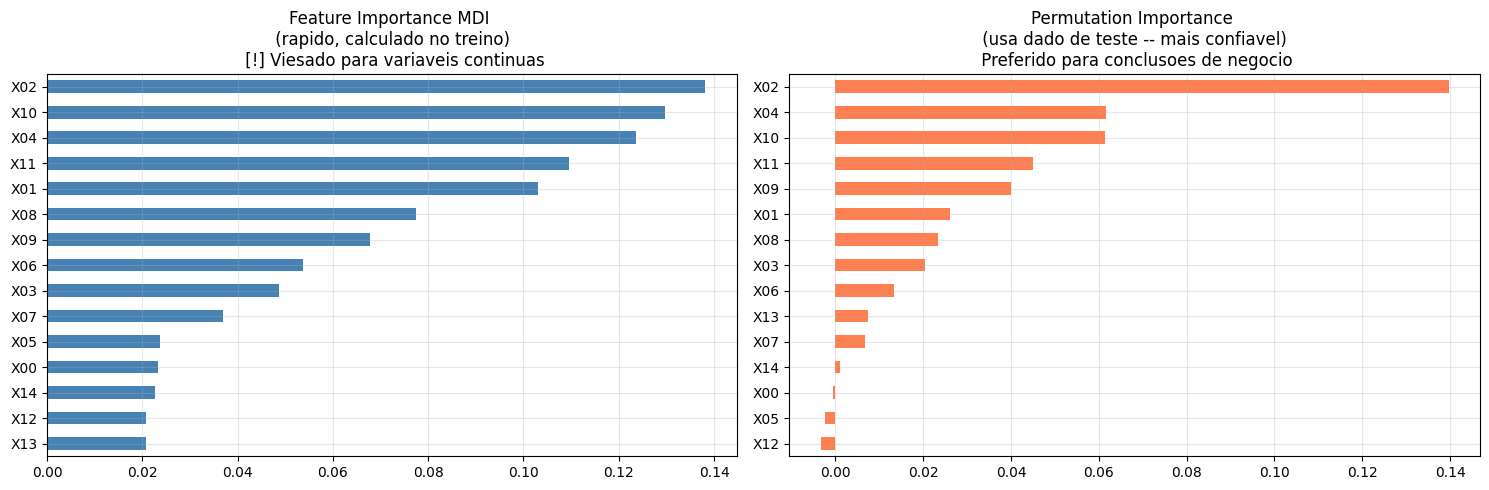

MDI: rapido mas viesado para variaveis com muitos valores unicos.
Permutation: lento mas usa dado de teste e e mais justo.
Prefira permutation importance para relatar ao negocio.


In [ ]:
# ============================================================
# 8.2 -- RANDOM FOREST: MAIS ARVORES NAO CAUSA OVERFIT
# ============================================================

np.random.seed(42)
X_rf, y_rf = make_classification(
    n_samples=1500, n_features=15, n_informative=8, random_state=42
)
X_tr_rf, X_te_rf, y_tr_rf, y_te_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

kf_rf = KFold(5, shuffle=False)

print("=== RANDOM FOREST: n_estimators NAO causa overfitting ===")
print()
print(f"{'n_estimators':>14} | {'AUC treino':>12} | {'AUC val':>10} | Nota")
print("-" * 60)

for n_est in [1, 5, 10, 50, 200, 500]:
    rf = RandomForestClassifier(
        n_estimators=n_est,   # numero de arvores na floresta
        max_depth=8,           # profundidade de cada arvore (fixo para comparacao)
        random_state=42
    )
    res_rf = cross_validate(rf, X_tr_rf, y_tr_rf, cv=kf_rf,
                             scoring='roc_auc', return_train_score=True)
    tr_rf = res_rf['train_score'].mean()
    va_rf = res_rf['test_score'].mean()
    nota  = "instavel" if n_est < 10 else ("estabilizando" if n_est < 50 else "estavel")
    print(f"{n_est:>14} | {tr_rf:>12.4f} | {va_rf:>10.4f} | {nota}")

print()
print("[!] MAIS ARVORES NAO CAUSA OVERFITTING EM RANDOM FOREST!")
print("  Com mais arvores, a variancia DIMINUI (media de mais variaveis).")
print("  O AUC de validacao converge para um platô -- nao cai.")
print("  Isso e diferente do XGBoost, onde lr alto + muitas arvores = overfit.")
print()
print("O QUE REALMENTE CAUSA OVERFITTING EM RANDOM FOREST:")
print("  - max_depth alto (arvores muito profundas)")
print("  - min_samples_leaf=1 (folhas com 1 amostra so)")
print("  - max_features muito alto (perde a aleatoriedade)")
print()

# Feature Importance: MDI vs Permutation
rf_final = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_final.fit(X_tr_rf, y_tr_rf)

fi_mdi = pd.Series(rf_final.feature_importances_,
                   index=[f'X{i:02d}' for i in range(X_rf.shape[1])])
perm_res = permutation_importance(rf_final, X_te_rf, y_te_rf,
                                   n_repeats=10, random_state=42)
fi_perm = pd.Series(perm_res.importances_mean,
                    index=[f'X{i:02d}' for i in range(X_rf.shape[1])])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fi_mdi.sort_values(ascending=True).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance MDI \n (rapido, calculado no treino) \n [!] Viesado para variaveis continuas')

fi_perm.sort_values(ascending=True).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Permutation Importance \n (usa dado de teste -- mais confiavel) \n Preferido para conclusoes de negocio')

plt.tight_layout()
plt.show()

print("MDI: rapido mas viesado para variaveis com muitos valores unicos.")
print("Permutation: lento mas usa dado de teste e e mais justo.")
print("Prefira permutation importance para relatar ao negocio.")

In [ ]:
# ============================================================
# 8.3 -- XGBOOST: OVERFITTING E COMO CORRIGIR
# ============================================================

np.random.seed(42)
X_xgb, y_xgb = make_classification(
    n_samples=1500, n_features=15, n_informative=9, random_state=42
)
X_tr_xgb, X_te_xgb, y_tr_xgb, y_te_xgb = train_test_split(
    X_xgb, y_xgb, test_size=0.2, random_state=42
)

print("=== XGBOOST: CONFIGURACOES E SEUS EFEITOS ===")
print()
print("Reproduzindo o padrao de overfitting (como aconteceu no Safra)")
print()
print(f"{'Configuracao':<50} {'AUC treino':>11} {'AUC teste':>10} {'Gap':>8}")
print("-" * 85)

configs_xgb = [
    (500, 0.50, 12, 0.0, "MAL: lr=0.5, depth=12, sem regularizacao", False),
    (500, 0.10,  6, 0.0, "MEDIO: lr ok, mas sem regularizacao",       False),
    (200, 0.10,  6, 1.0, "BOM: lr ok + regularizacao L2",             False),
    (500, 0.05,  4, 1.0, "OTIMO: lr baixo + early stopping + L2",     True),
]

for n_est, lr, depth, lam, desc, use_es in configs_xgb:
    xgb = XGBClassifier(
        n_estimators=n_est,
        learning_rate=lr,              # tamanho do passo: menor = mais conservador
        max_depth=depth,               # profundidade de cada arvore individual
        reg_lambda=lam,                # regularizacao L2 nos pesos das folhas
        eval_metric='logloss',
        early_stopping_rounds=40 if use_es else None,
        verbosity=0,
        random_state=42
    )

    if use_es:
        xgb.fit(X_tr_xgb, y_tr_xgb,
                eval_set=[(X_te_xgb, y_te_xgb)],
                verbose=False)
        n_usado = xgb.best_iteration
    else:
        xgb.fit(X_tr_xgb, y_tr_xgb)
        n_usado = n_est

    auc_tr = roc_auc_score(y_tr_xgb, xgb.predict_proba(X_tr_xgb)[:,1])
    auc_te = roc_auc_score(y_te_xgb, xgb.predict_proba(X_te_xgb)[:,1])

    print(f"{desc:<50} {auc_tr:>11.4f} {auc_te:>10.4f} {auc_tr-auc_te:>8.4f}  ({n_usado} arvores)")

print()
print("COMO CORRIGIR OVERFITTING NO XGBOOST (em ordem de importancia):")
print()
print("  1. early_stopping_rounds:")
print("     Para automaticamente quando val nao melhora por N rounds.")
print("     Nao precisa escolher n_estimators manualmente.")
print()
print("  2. Reduza learning_rate (0.05-0.10 em vez de 0.3+):")
print("     Passos menores = mais conservador = melhor generalizacao.")
print("     Compensar com mais n_estimators + early stopping.")
print()
print("  3. Reduza max_depth (3-6):")
print("     Arvores menos profundas = cada uma menos especializada.")
print()
print("  4. Aumente reg_lambda (L2):")
print("     Penaliza pesos grandes nas folhas.")
print()
print("  5. subsample e colsample_bytree (0.7-0.9):")
print("     Amostragem de dados e features por arvore = mais diversidade.")
print()
print("[!] DIFERENCA CRITICA RF vs XGBOOST:")
print()
print("  Random Forest:")
print("    - Arvores treinadas em PARALELO (independentes)")
print("    - SEM learning_rate (bagging nao usa)")
print("    - Overfitting: max_depth alto")
print("    - Mais arvores = mais estavel (nao mais overfit)")
print()
print("  XGBoost:")
print("    - Arvores treinadas SEQUENCIALMENTE (uma corrige a anterior)")
print("    - TEM learning_rate (controla o passo do boosting)")
print("    - Overfitting: lr alto + muitas arvores + depth alto")
print("    - TEM early stopping (para antes de overfittar)")

=== XGBOOST: CONFIGURACOES E SEUS EFEITOS ===

Reproduzindo o padrao de overfitting (como aconteceu no Safra)

Configuracao                                        AUC treino  AUC teste      Gap
-------------------------------------------------------------------------------------
MAL: lr=0.5, depth=12, sem regularizacao                1.0000     0.9808   0.0192  (500 arvores)
MEDIO: lr ok, mas sem regularizacao                     1.0000     0.9790   0.0210  (500 arvores)
BOM: lr ok + regularizacao L2                           1.0000     0.9783   0.0217  (200 arvores)
OTIMO: lr baixo + early stopping + L2                   0.9996     0.9727   0.0269  (213 arvores)

COMO CORRIGIR OVERFITTING NO XGBOOST (em ordem de importancia):

  1. early_stopping_rounds:
     Para automaticamente quando val nao melhora por N rounds.
     Nao precisa escolher n_estimators manualmente.

  2. Reduza learning_rate (0.05-0.10 em vez de 0.3+):
     Passos menores = mais conservador = melhor generalizacao.
 

In [ ]:
# ============================================================
# QUESTOES DO MODULO 8
# ============================================================

print("=" * 65)
print("QUESTOES DO MODULO 8 -- Resolva antes de ver o gabarito")
print("=" * 65)
print()
print("QUESTAO 1 (calculo -- Q24 da prova real):")
print("  Um banco tem base historica de 10 milhoes de transacoes.")
print("  Arvore de decisao sem restricao de profundidade.")
print("  Qual a profundidade maxima que ela pode atingir?")
print()
print("QUESTAO 2 (diagnostico -- Q20 da prova real):")
print("  Arvore: criterion='entropy', sem poda, KFold(10, shuffle=False).")
print("  Candidato A: 'Log Loss treino = 0.8, val = 3.2'")
print("  Candidato B: 'Log Loss treino ~= 0.0, val = 3.2'")
print("  Quem esta certo? Por que?")
print()
print("QUESTAO 3 (conceitual -- pegadinha classica):")
print("  Gestor diz: 'Aumentei o Random Forest de 100 para 500 arvores")
print("  e o AUC de validacao nao mudou. O modelo esta overfittando.'")
print("  Voce concorda? O que realmente causa overfitting em RF?")
print()
print("-" * 65)
print()

n_tx = 10_000_000
prof = math.ceil(math.log2(n_tx))

print("GABARITOS:")
print()
print(f"Q1: ceil(log2({n_tx:,})) = ceil({math.log2(n_tx):.2f}) = {prof}")
print()
print(f"  ATENCAO: esta e a profundidade MAXIMA TEORICA sem restricao.")
print(f"  Na pratica NUNCA use arvore sem max_depth.")
print(f"  Uma arvore de profundidade {prof} com {n_tx:,} amostras")
print(f"  poderia ter 2^{prof:,} = {2**prof:,} folhas -- overfitting total.")
print()
print("Q2: O CANDIDATO B esta certo. Log Loss treino ~= 0.")
print()
print("  Arvore sem poda cria folhas com 1 amostra de uma so classe.")
print("  Probabilidade prevista: 1.0 para a classe correta no treino.")
print("  -log(1.0) = 0 -> contribuicao zero para o Log Loss.")
print("  Todas as folhas puras: Log Loss treino = 0.")
print()
print("  Na validacao: amostras novas caem em folhas especializadas demais.")
print("  Quando erra, probabilidades extremas -> Log Loss de validacao explode.")
print()
print("  O Candidato A errou porque:")
print("  (a) Nao sabia que arvore sem poda tem LL treino ~= 0")
print("  (b) Pode ter confundido com acuracia")
print("  (c) Pode ter achado que Log Loss nao era valida para classificacao")
print("      -- mas e valida e muito usada!")
print()
print("Q3: NAO concordo. Mais arvores NAO causa overfitting em RF.")
print()
print("  Mais arvores em RF -> variancia MENOR -> modelo mais estavel.")
print("  O AUC nao mudou porque o modelo JA convergiu -- normal e esperado.")
print("  Ha um ponto de retorno decrescente: apos ~200-500 arvores,")
print("  adicionar mais nao ajuda nem prejudica.")
print()
print("  O QUE realmente causa overfitting em Random Forest:")
print("  - max_depth muito alto")
print("  - min_samples_leaf = 1 (folha com 1 amostra)")
print("  - min_samples_split muito baixo")
print()
print("  Como diagnosticar: testar diferentes max_depth com CV.")
print("  Se AUC de validacao cai com max_depth maior: overfitting por profundidade.")

QUESTOES DO MODULO 8 -- Resolva antes de ver o gabarito

QUESTAO 1 (calculo -- Q24 da prova real):
  Um banco tem base historica de 10 milhoes de transacoes.
  Arvore de decisao sem restricao de profundidade.
  Qual a profundidade maxima que ela pode atingir?

QUESTAO 2 (diagnostico -- Q20 da prova real):
  Arvore: criterion='entropy', sem poda, KFold(10, shuffle=False).
  Candidato A: 'Log Loss treino = 0.8, val = 3.2'
  Candidato B: 'Log Loss treino ~= 0.0, val = 3.2'
  Quem esta certo? Por que?

QUESTAO 3 (conceitual -- pegadinha classica):
  Gestor diz: 'Aumentei o Random Forest de 100 para 500 arvores
  e o AUC de validacao nao mudou. O modelo esta overfittando.'
  Voce concorda? O que realmente causa overfitting em RF?

-----------------------------------------------------------------

GABARITOS:

Q1: ceil(log2(10,000,000)) = ceil(23.25) = 24

  ATENCAO: esta e a profundidade MAXIMA TEORICA sem restricao.
  Na pratica NUNCA use arvore sem max_depth.
  Uma arvore de profundidade 2